### Home Task

Titanic - Machine Learning from Disaster

Predict survival


In [386]:
import os
import numpy as np
import pandas as pd

# get path current working directory
cwd= os.getcwd() 
path = os.path.join(cwd,'data')


Load train and test data

In [387]:
def get_train_set():
    print ('loading provided train set.')
    fp = os.path.join(path,'train.csv')
    return pd.read_csv(fp)

df_train = get_train_set()
df_train.head()

loading provided train set.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [388]:
def get_test_set():
    print ('loading provided test set.')
    fp = os.path.join(path, 'test.csv')
    return pd.read_csv(fp)

df_test = get_test_set()
df_test.head()

loading provided test set.


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


train and test split data

In [389]:
def get_X_train_test(df_train, df_test):
    # drop columns that are not useful for training
    
    columns_for_train = df_train.columns.drop(['PassengerId','Survived', 'Name', 'Ticket', 'Cabin'])

    X_train = df_train[columns_for_train]
    X_test = df_test[columns_for_train]
    return X_train, X_test, columns_for_train

X_train, X_test, features = get_X_train_test(df_train, df_test) 

y_train = df_train['Survived']

print("shape train data: ", X_train.shape)
print("shape test data: ", X_test.shape)


shape train data:  (891, 7)
shape test data:  (418, 7)


Encoding columns with dtype object

In [390]:
X_train.dtypes

Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [391]:

columns_to_encode = X_train.columns[X_train.dtypes == 'object']
columns_to_encode


Index(['Sex', 'Embarked'], dtype='object')

In [392]:
from sklearn.preprocessing import LabelEncoder

In [393]:
def label_encoder(X_train, X_test):    
    print ('label encoding.')
    X_train = X_train.copy()  

    for col in columns_to_encode:
        le = LabelEncoder().fit(X_train[col].astype(str)) 
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
    return X_train,X_test

X_train, X_test = label_encoder(X_train, X_test)
X_train.dtypes

label encoding.


C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))


Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

handling the missing values NaN

In [394]:
# check the na columns 

X_train.isna().any()

Pclass      False
Sex         False
Age          True
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

In [395]:
def fill_na(df):
    print ('filling NaN...')
    for col in list(df):
        if df[col].isna().any():
            df[col]= df[col].fillna(0)

fill_na(X_train)
fill_na(X_test) 

X_train.isna().any().any(), X_test.isna().any().any()

filling NaN...
filling NaN...


C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\1156397169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]= df[col].fillna(0)


(np.False_, np.False_)

Normalize the data

In [396]:
from sklearn.preprocessing import MinMaxScaler

In [397]:
def normalize(X_train, X_test):
    print ('normalizing.')
    scaler= MinMaxScaler()
    X_train_scaled= scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled 

X_train_scaled, X_test_scaled  = normalize(X_train, X_test)
type(X_train_scaled)

normalizing.


numpy.ndarray

Choose the best classifier

In [398]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier

from sklearn.metrics import f1_score

In [399]:
import matplotlib.pyplot as plt
def result_feature_importances(clf, features): 
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    
    res = np.arange(c_features), features
    return res
    

In [400]:
def run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train, y_test= None):
    print ('Running GridSearchCV.')
    grid_clf = GridSearchCV(clf, param_grid=grid_values,scoring='f1')
    grid_clf.fit(X_train_scaled, y_train)
    print('Grid best parameter (max f1 ): ', grid_clf.best_params_) 
    print('Grid best score (f1): ', grid_clf.best_score_) 

    if not y_test is None:
        test_score= grid_clf.score(X_test_scaled, y_test)
        print("test f1= {}".format(test_score))


In [401]:
 
def run_all_classifiers(X_train_scaled, X_test_scaled, y_train, y_test=None, list_classifiers= None):
    
    if list_classifiers is None or 'LogisticRegression' in list_classifiers:
        print ('\nLogisticRegression.')
        clf = LogisticRegression(max_iter=10000)
        grid_values = {'C': [0.005, 0.01,0.1, 1, 100, 10000, 100000]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled,  y_train,  y_test= y_test)
 

    if list_classifiers is None or 'DecisionTreeClassifier' in list_classifiers:
        print ('\nDecisionTreeClassifier')
        clf = DecisionTreeClassifier()       
        grid_values = {'max_depth': [2,5,7, 20, 50]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   
 

    if list_classifiers is None or 'RandomForestClassifier' in list_classifiers:
        print ('\nRandomForestClassifier.')
        clf = RandomForestClassifier()       
        grid_values = {'n_estimators': [20,50,200,300]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   
 

    if list_classifiers is None or 'SVC_poly' in list_classifiers:
        print ('\nSVC_poly')
        clf = SVC(kernel='poly')           
        grid_values = {'C': [0.01, 0.1, 1, 100, ]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   
 

    if list_classifiers is None or 'SVC_rbf' in list_classifiers:
        print ('\nSVC_rbf')
        clf = SVC(kernel='rbf')
        grid_values = {'C': [0.005, 0.01, 0.02, 0.03, 0.1, 1, 100, 10000], 'gamma':[0.001, 0.01, 0.1]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   
       

    if list_classifiers is None or 'NB' in list_classifiers:
        print ('\nNB')
        clf =  GaussianNB().fit(X_train_scaled, y_train)
        train_f1 = f1_score(y_train, clf.predict(X_train_scaled))
        print("train set f1= {}".format(train_f1))
        if not y_test is None:
            test_f1 = f1_score(y_test, clf.predict(X_test_scaled))
            print("test set f1= {}".format(test_f1))
         
  
    if list_classifiers is None or 'GradientBoostingClassifier' in list_classifiers:
        print ('\nGradientBoostingClassifier.')
        clf = GradientBoostingClassifier()     
        grid_values = {'max_depth': [3,5,7]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   
         
    
    if list_classifiers is None or 'MLP' in list_classifiers:
        print ('\nMLP.')
        clf = MLPClassifier(hidden_layer_sizes = [50, 100])
        grid_values = {'alpha' : [0.001, 0.01, 0.1, 1, 10]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   
 

    if list_classifiers is None or 'xgboost' in list_classifiers:
        print ('\nxgboost.')
        clf = XGBClassifier().fit(X_train_scaled, y_train)
        grid_values = {'max_depth' : [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300]}
        run_GridSearchCV(clf, grid_values, X_train_scaled, X_test_scaled, y_train, y_test = y_test)
  
  

In [402]:
def apply_preprocessing(df_train, df_test):  
 
    X_train, X_test, features  = get_X_train_test(df_train, df_test)
    
    X_train, X_test= label_encoder(X_train,X_test)
    
    y_train = df_train['Survived']
    if 'Survived' in list(df_test):     
        y_test = df_test['Survived'] # test set  as outcome of train_test_split of provided train set  
    else: 
        y_test = None # provided test set 
   
    fill_na(X_train)
    fill_na(X_test)

    X_train_scaled, X_test_scaled  = normalize(X_train, X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features

In [403]:
from sklearn.model_selection import train_test_split

In [404]:
df= get_train_set()

df_train, df_test = train_test_split(df, random_state= 0)
X_train_scaled, X_test_scaled, y_train, y_test, features = apply_preprocessing(df_train, df_test)

print ('X_train_scaled shape= {}\nX_test_scaled shape= {}'.format(X_train_scaled.shape, X_test_scaled.shape))
print ('y_train set shape= {}\ny_test set shape= {}'.format(y_train.shape, y_test.shape))

loading provided train set.
label encoding.
filling NaN...
filling NaN...
normalizing.
X_train_scaled shape= (668, 7)
X_test_scaled shape= (223, 7)
y_train set shape= (668,)
y_test set shape= (223,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\1156397169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [405]:
list_classifiers= [
    'LogisticRegression',
    'DecisionTreeClassifier',
    'RandomForestClassifier',
    'NB',
    'GradientBoostingClassifier', 
    'xgboost'
]
run_all_classifiers(X_train_scaled, X_test_scaled, y_train, y_test, list_classifiers= list_classifiers)


LogisticRegression.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'C': 10000}
Grid best score (f1):  0.7139575052408803
test f1= 0.7368421052631579

DecisionTreeClassifier
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 7}
Grid best score (f1):  0.7199725141720543
test f1= 0.7329192546583851

RandomForestClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'n_estimators': 300}
Grid best score (f1):  0.7370333490360912
test f1= 0.7662337662337663

NB
train set f1= 0.7279843444227005
test set f1= 0.7262569832402235

GradientBoostingClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 5}
Grid best score (f1):  0.7382488141753966
test f1= 0.7530864197530864

xgboost.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Grid best score (f1):  0.7528903930828096
test f1= 0.7625


In [406]:
df_train= get_train_set()
df_test= get_test_set()

X_train_scaled_1, X_test_scaled_1, y_train_1, y_test_1, features = apply_preprocessing(df_train, df_test)

print ('X_train_scaled shape= {}\nX_test_scaled shape= {}'.format(X_train_scaled_1.shape, X_test_scaled_1.shape))
print ('y_train set shape= {}'.format(y_train_1.shape))
print ('y_test type = {}'.format(type(y_test_1)))

loading provided train set.
loading provided test set.
label encoding.
filling NaN...
filling NaN...
normalizing.
X_train_scaled shape= (891, 7)
X_test_scaled shape= (418, 7)
y_train set shape= (891,)
y_test type = <class 'NoneType'>


C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\2965084096.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = le.transform(X_test[col].astype(str))
C:\Users\Admin\AppData\Local\Temp\ipykernel_8036\1156397169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [407]:
list_classifiers= [
    'LogisticRegression',
    'DecisionTreeClassifier',
    'RandomForestClassifier',
    'NB',
    'GradientBoostingClassifier', 
    'xgboost',
]
run_all_classifiers(X_train_scaled_1, X_test_scaled_1, y_train_1, y_test_1, list_classifiers= list_classifiers)


LogisticRegression.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'C': 100}
Grid best score (f1):  0.7131121097734029

DecisionTreeClassifier
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 7}
Grid best score (f1):  0.7156949403363146

RandomForestClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'n_estimators': 50}
Grid best score (f1):  0.7456183370153633

NB
train set f1= 0.7251461988304093

GradientBoostingClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 5}
Grid best score (f1):  0.7571907595311912

xgboost.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
Grid best score (f1):  0.7698595895960059


In [408]:
# Use the best parameters for xgboost 
print ('\nxgboost.')
clf_XGBC = XGBClassifier(
      n_estimators = 300,
      max_depth = 5,
      learning_rate = 0.05,
).fit(X_train_scaled_1, y_train_1)

# Evaluate the model on the train   
print("train accuracy= {:.3%}".format(clf_XGBC.score(X_train_scaled_1, y_train_1)))
train_f1 = f1_score(y_train_1, clf_XGBC.predict(X_train_scaled_1))
print("train set f1= {}".format(train_f1))

# Evaluate if test set is not null
if not y_test_1 is None:
      print("test accuracy= {:.3%}".format(clf_XGBC.score(X_test_scaled_1, y_test_1)))
      test_f1 = f1_score(y_test_1, clf_XGBC.predict(X_test_scaled_1))
      print("test set f1= {}".format(test_f1))



xgboost.
train accuracy= 93.154%
train set f1= 0.9065849923430321


Feature importance

In [409]:
import matplotlib.pyplot as plt
def plot_feature_importances(clf, features):
    plt.figure(figsize=(10, 7), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)
    plt.show()
    

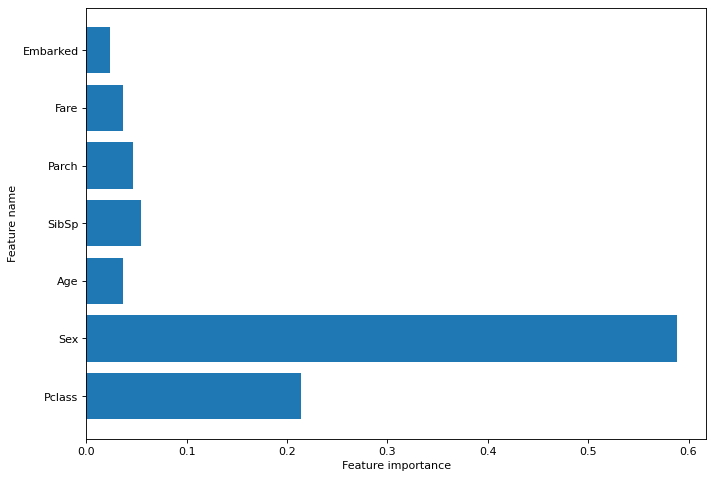

array([0.21390978, 0.58830076, 0.03698824, 0.05436902, 0.04665455,
       0.0361565 , 0.02362116], dtype=float32)

In [410]:

plot_feature_importances(clf_XGBC, features)
clf_XGBC.feature_importances_ 